In [ ]:
import os
import joblib
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [ ]:
# 1. LOAD DATA


file_path = "/content/step3_engineered_dataset.csv"
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (552, 53)

Columns:
['Student ID', 'Gender', 'Type of Examinee', 'Pre-assessment 2025', 'Anatomy', 'Physiology', 'Parasitology', 'Pharmacology', 'Pathology', 'Zootechnics', 'Microbiology & Public Health', 'Medicine', 'Surgery', 'Post-assessment 2025', 'Pre-assessment 2025_last', 'Anatomy_last', 'Physiology_last', 'Parasitology_last', 'Pharmacology_last', 'Pathology_last', 'Zootechnics_last', 'Microbiology & Public Health_last', 'Medicine_last', 'Surgery_last', 'Post-assessment 2025_last', 'Pre-assessment 2025_best', 'Anatomy_best', 'Physiology_best', 'Parasitology_best', 'Pharmacology_best', 'Pathology_best', 'Zootechnics_best', 'Microbiology & Public Health_best', 'Medicine_best', 'Surgery_best', 'Post-assessment 2025_best', 'avg_best_score', 'max_best_score', 'avg_first_score', 'avg_last_score', 'total_attempts', 'avg_attempts', 'avg_improvement', 'score_std', 'num_exams', 'Licensure Exam Result', 'exam_coverage_ratio', 'best_minus_first', 'last_minus_first', 'best_min

In [ ]:
# 2. TARGET AND FEATURES


target_col = "Licensure Exam Result"
drop_cols = ["Student ID"]  # identifier only

X = df.drop(columns=drop_cols + [target_col])
y = df[target_col]

# Detect column types
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("\nCategorical columns:", categorical_cols)
print("Number of numeric columns:", len(numeric_cols))


Categorical columns: ['Gender', 'Type of Examinee']
Number of numeric columns: 49


In [ ]:
# 3. TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (441, 51)
Test shape: (111, 51)


In [ ]:
# 4. PREPROCESSORS

numeric_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_unscaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# For models that need scaling
preprocessor_scaled = ColumnTransformer([
    ("num", numeric_scaled, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

# For tree-based models
preprocessor_unscaled = ColumnTransformer([
    ("num", numeric_unscaled, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

In [ ]:
# 5. BUILD MODELS


log_reg_pipe = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("model", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ))
])

decision_tree_pipe = Pipeline([
    ("preprocessor", preprocessor_unscaled),
    ("model", DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced",
        max_depth=5,
        min_samples_leaf=10
    ))
])

svm_pipe = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("model", SVC(
        probability=True,
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced",
        random_state=42
    ))
])

random_forest_pipe = Pipeline([
    ("preprocessor", preprocessor_unscaled),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1,
        min_samples_leaf=2,
        min_samples_split=5
    ))
])

xgboost_pipe = Pipeline([
    ("preprocessor", preprocessor_unscaled),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42,
        n_jobs=1
    ))
])

models = {
    "Logistic Regression": log_reg_pipe,
    "Decision Tree": decision_tree_pipe,
    "Support Vector Machine": svm_pipe,
    "Random Forest": random_forest_pipe,
    "XGBoost": xgboost_pipe
}

In [ ]:
# 6. CROSS-VALIDATION SETUP


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "auc": "roc_auc",
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

In [ ]:
# 7. BASELINE MODEL COMPARISON

results = []

for model_name, pipeline in models.items():
    print(f"\nRunning: {model_name}")

    cv_scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1
    )

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": model_name,
        "CV AUC Mean": np.mean(cv_scores["test_auc"]),
        "CV Accuracy Mean": np.mean(cv_scores["test_accuracy"]),
        "CV Precision Mean": np.mean(cv_scores["test_precision"]),
        "CV Recall Mean": np.mean(cv_scores["test_recall"]),
        "CV F1 Mean": np.mean(cv_scores["test_f1"]),
        "Test AUC": roc_auc_score(y_test, y_prob),
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Test Precision": precision_score(y_test, y_pred),
        "Test Recall": recall_score(y_test, y_pred),
        "Test F1": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).sort_values(by="Test AUC", ascending=False)
print("\n=== BASELINE MODEL COMPARISON ===")
print(results_df.round(4))

# Save baseline results
results_df.to_csv("/content/step4_baseline_model_comparison.csv", index=False)



Running: Logistic Regression

Running: Decision Tree

Running: Support Vector Machine

Running: Random Forest

Running: XGBoost

=== BASELINE MODEL COMPARISON ===
                    Model  CV AUC Mean  CV Accuracy Mean  CV Precision Mean  \
3           Random Forest       0.7195            0.7461             0.7826   
2  Support Vector Machine       0.7261            0.6895             0.8291   
4                 XGBoost       0.6897            0.7258             0.7787   
0     Logistic Regression       0.6358            0.6123             0.7937   
1           Decision Tree       0.6307            0.6054             0.8069   

   CV Recall Mean  CV F1 Mean  Test AUC  Test Accuracy  Test Precision  \
3          0.9038      0.8386    0.8317         0.7838          0.8065   
2          0.7268      0.7739    0.8177         0.7297          0.8228   
4          0.8728      0.8222    0.8033         0.7748          0.8043   
0          0.6338      0.7044    0.7642         0.6937          0

In [ ]:
# 8. HYPERPARAMETER TUNING

# 8A. Random Forest tuning

rf_base = Pipeline([
    ("preprocessor", preprocessor_unscaled),
    ("model", RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_param_dist = {
    "model__n_estimators": [200, 300, 400],
    "model__max_depth": [None, 6, 10, 14],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_dist,
    n_iter=8,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=1
)

rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

rf_pred = best_rf.predict(X_test)
rf_prob = best_rf.predict_proba(X_test)[:, 1]


# 8B. XGBoost tuning

xgb_base = Pipeline([
    ("preprocessor", preprocessor_unscaled),
    ("model", XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        n_jobs=1
    ))
])

xgb_param_dist = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 4, 5, 6],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__subsample": [0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.8, 0.9, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=8,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=1
)

xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_

xgb_pred = best_xgb.predict(X_test)
xgb_prob = best_xgb.predict_proba(X_test)[:, 1]


# 8C. SVM tuning

svm_base = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("model", SVC(
        probability=True,
        class_weight="balanced",
        random_state=42
    ))
])

svm_param_dist = {
    "model__C": [0.1, 1, 10, 50],
    "model__gamma": ["scale", 0.01, 0.1, 1],
    "model__kernel": ["rbf", "linear"]
}

svm_search = RandomizedSearchCV(
    estimator=svm_base,
    param_distributions=svm_param_dist,
    n_iter=8,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=1
)

svm_search.fit(X_train, y_train)
best_svm = svm_search.best_estimator_

svm_pred = best_svm.predict(X_test)
svm_prob = best_svm.predict_proba(X_test)[:, 1]


In [ ]:
# 9. TUNED MODEL RESULTS

tuned_results = pd.DataFrame([
    {
        "Model": "Tuned Random Forest",
        "Best CV AUC": rf_search.best_score_,
        "Test AUC": roc_auc_score(y_test, rf_prob),
        "Test Accuracy": accuracy_score(y_test, rf_pred),
        "Test Precision": precision_score(y_test, rf_pred),
        "Test Recall": recall_score(y_test, rf_pred),
        "Test F1": f1_score(y_test, rf_pred),
        "Best Params": rf_search.best_params_
    },
    {
        "Model": "Tuned XGBoost",
        "Best CV AUC": xgb_search.best_score_,
        "Test AUC": roc_auc_score(y_test, xgb_prob),
        "Test Accuracy": accuracy_score(y_test, xgb_pred),
        "Test Precision": precision_score(y_test, xgb_pred),
        "Test Recall": recall_score(y_test, xgb_pred),
        "Test F1": f1_score(y_test, xgb_pred),
        "Best Params": xgb_search.best_params_
    },
    {
        "Model": "Tuned SVM",
        "Best CV AUC": svm_search.best_score_,
        "Test AUC": roc_auc_score(y_test, svm_prob),
        "Test Accuracy": accuracy_score(y_test, svm_pred),
        "Test Precision": precision_score(y_test, svm_pred),
        "Test Recall": recall_score(y_test, svm_pred),
        "Test F1": f1_score(y_test, svm_pred),
        "Best Params": svm_search.best_params_
    }
]).sort_values(by="Test AUC", ascending=False)

print("\n=== TUNED MODEL COMPARISON ===")
print(tuned_results.round(4))

# Save tuned results
tuned_results.to_csv("/content/step4_tuned_model_comparison.csv", index=False)



=== TUNED MODEL COMPARISON ===
                 Model  Best CV AUC  Test AUC  Test Accuracy  Test Precision  \
0  Tuned Random Forest       0.7275    0.8424         0.7928          0.8222   
2            Tuned SVM       0.7361    0.8177         0.7297          0.8228   
1        Tuned XGBoost       0.6976    0.8091         0.7748          0.7917   

   Test Recall  Test F1                                        Best Params  
0       0.9136   0.8655  {'model__n_estimators': 200, 'model__min_sampl...  
2       0.8025   0.8125  {'model__kernel': 'rbf', 'model__gamma': 'scal...  
1       0.9383   0.8588  {'model__subsample': 0.8, 'model__n_estimators...  


In [ ]:
# 10. CHOOSE FINAL MODEL


final_model_name = tuned_results.iloc[0]["Model"]
print("\nFinal selected model:", final_model_name)

if final_model_name == "Tuned Random Forest":
    best_model = best_rf
elif final_model_name == "Tuned XGBoost":
    best_model = best_xgb
else:
    best_model = best_svm



Final selected model: Tuned Random Forest


In [ ]:
# 11. SAVE MODELS FOR REPRODUCIBILITY

os.makedirs("/content/models", exist_ok=True)

joblib.dump(best_rf, "/content/models/random_forest_final.pkl")
joblib.dump(best_xgb, "/content/models/xgboost_final.pkl")
joblib.dump(best_svm, "/content/models/svm_final.pkl")
joblib.dump(best_model, "/content/models/final_selected_model.pkl")
joblib.dump(X.columns.tolist(), "/content/models/feature_names.pkl")

print("\nModels saved successfully.")


Models saved successfully.


In [ ]:
# 12. LOAD MODEL TEST


loaded_model = joblib.load("/content/models/final_selected_model.pkl")
sample_preds = loaded_model.predict(X_test.iloc[:5])

print("\nSample predictions from loaded model:")
print(sample_preds)


Sample predictions from loaded model:
[1 1 1 0 1]


In [ ]:
# 13. FEATURE IMPORTANCE ANALYSIS

# Get the feature names after preprocessing
def get_preprocessor_feature_names(preprocessor, numeric_cols, categorical_cols):
    output_features = []

    # Numeric features (imputer does not change names)
    output_features.extend(numeric_cols)

    # Categorical features (one-hot encoder creates new names)
    # Access the 'onehot' step within the 'cat' transformer
    ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
    output_features.extend(ohe.get_feature_names_out(categorical_cols))

    return output_features

# Assuming best_model is already defined from cell 43jKXFZCaJJ_
# Access the preprocessor from the best_model pipeline
preprocessor_for_best_model = best_model.named_steps['preprocessor']

# Get the feature names
feature_names = get_preprocessor_feature_names(preprocessor_for_best_model, numeric_cols, categorical_cols)

# Get feature importances from the trained Random Forest model
# The actual RandomForestClassifier model is inside the 'model' step of the pipeline
feature_importances = best_model.named_steps['model'].feature_importances_

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("\nTop 15 Most Predictive Features for Licensure Success:")
display(importance_df.head(15))


Top 15 Most Predictive Features for Licensure Success:


,Feature,Importance
35,avg_first_score,0.051162
36,avg_last_score,0.034743
40,score_std,0.031632
48,score_range_proxy,0.031579
33,avg_best_score,0.031206
6,Zootechnics,0.030558
0,Pre-assessment 2025,0.029759
37,total_attempts,0.028970
47,stability_index,0.028736
2,Physiology,0.024887


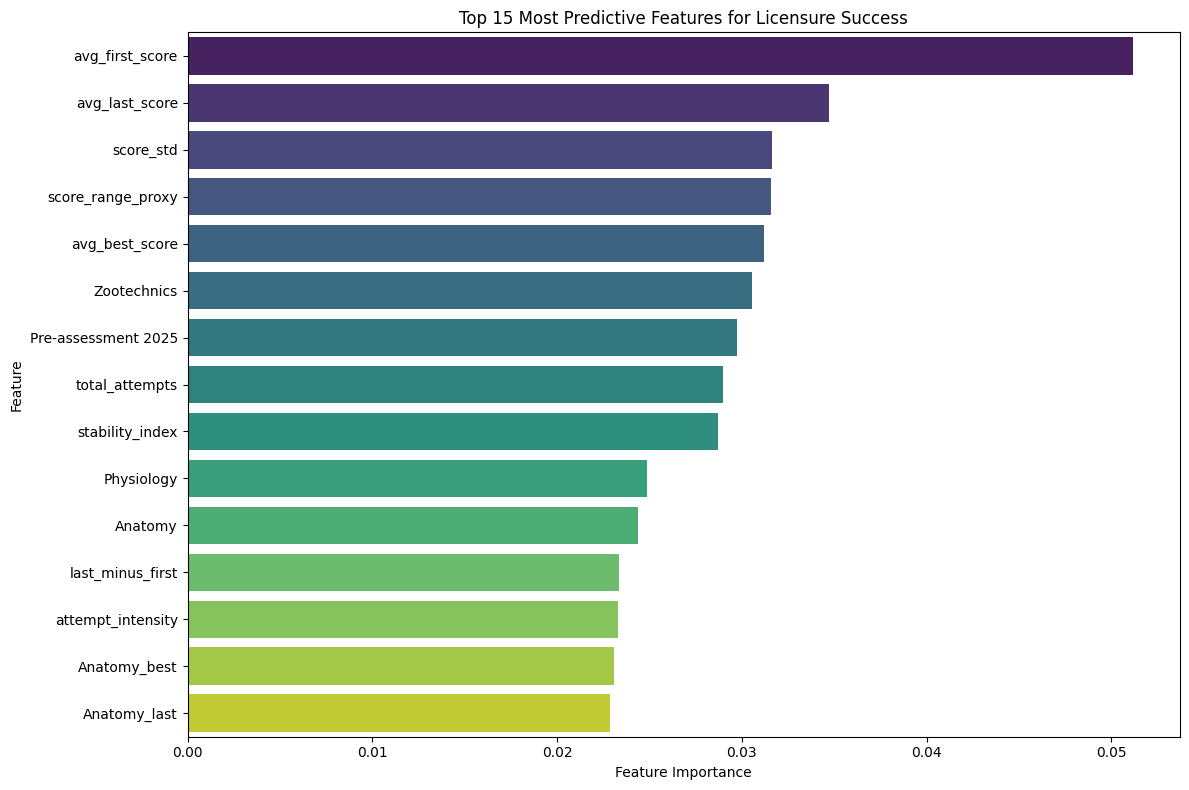

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the top 15 features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis')
plt.title('Top 15 Most Predictive Features for Licensure Success')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Here's how to interpret and communicate the 'Importance' values:

*   **What they mean**: The 'Importance' values (e.g., 0.05, 0.04, etc.) are derived from the model's internal calculations (in this case, Gini impurity reduction for the Random Forest). They indicate how much each feature contributes to the model's predictive power.

*   **Are they percentages?**: Yes, implicitly. These values are typically normalized such that the sum of all feature importances across all features in the model adds up to 1.0 (or 100%). So, an importance of 0.05 means that feature contributes 5% to the total importance in the model's decision-making process.

*   **How to interpret**: A higher 'Importance' value indicates that the feature plays a more significant role in predicting the 'Licensure Exam Result'. For example, if 'avg_first_score' has an importance of 0.051, it means it's the most influential feature among those displayed, contributing approximately 5.1% to the model's predictive decisions.

*   **How to communicate**: You can say:
    *   "Features with higher importance values are more predictive of licensure success."
    *   "The 'avg_first_score' is the most important feature, contributing about 5.1% to the model's predictions."
    *   "These values provide insights into which aspects of a student's profile (scores, attempts, etc.) are most crucial for determining their licensure exam outcome."

In essence, these values help us understand which factors the model relies on most heavily to make its predictions.

The top 3 features that are most predictive of licensure success, according to Tuned Random Forest model, are:

avg_first_score: This feature likely represents the average score a student achieved on their initial attempts or early assessments. A higher average first score suggests a strong initial grasp of the subject matter or good preparedness from the start, which could be a significant indicator of eventual success in the licensure exam.

avg_last_score: This feature probably indicates the average score a student obtained on their most recent or final assessments leading up to the licensure exam. A high average last score often signifies that the student has improved their knowledge, learned effectively, or retained information well close to the exam date, thereby boosting their chances of success.

score_std: This stands for standard deviation of scores, which is a measure of the dispersion or variability of a student's scores across all their assessments. A lower score_std implies that the student's performance has been very consistent throughout their studies. This consistency is generally a strong positive predictor, as it suggests reliable knowledge and fewer fluctuations in understanding, which are critical for a high-stakes exam like licensure.

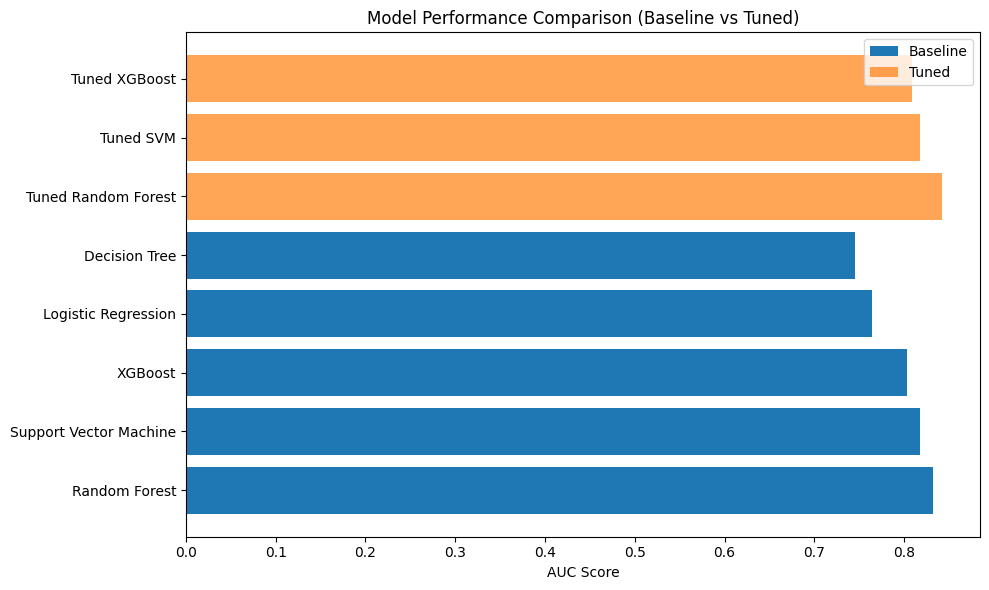

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

baseline = pd.read_csv("/content/step4_baseline_model_comparison.csv")
tuned = pd.read_csv("/content/step4_tuned_model_comparison.csv")

plt.figure(figsize=(10,6))

plt.barh(baseline["Model"], baseline["Test AUC"], label="Baseline")
plt.barh(tuned["Model"], tuned["Test AUC"], alpha=0.7, label="Tuned")

plt.xlabel("AUC Score")
plt.title("Model Performance Comparison (Baseline vs Tuned)")
plt.legend()
plt.tight_layout()
plt.savefig("final_model_comparison.png")
plt.show()

In [ ]:
final_model_name = tuned_results.iloc[0]["Model"]

<Axes: xlabel='Importance', ylabel='Feature'>

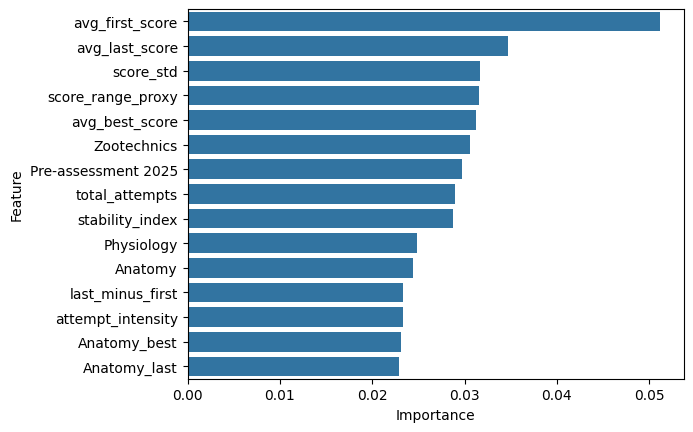

In [ ]:
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))

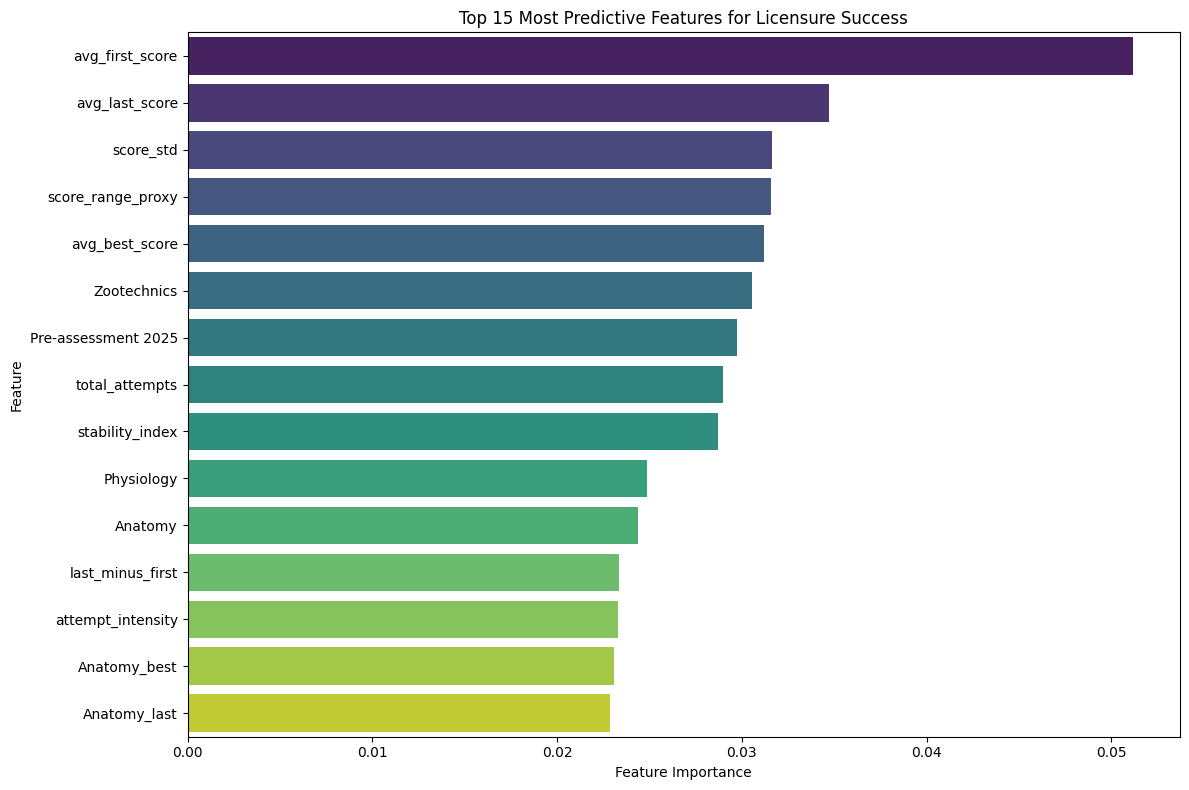

In [ ]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis')
plt.title('Top 15 Most Predictive Features for Licensure Success')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

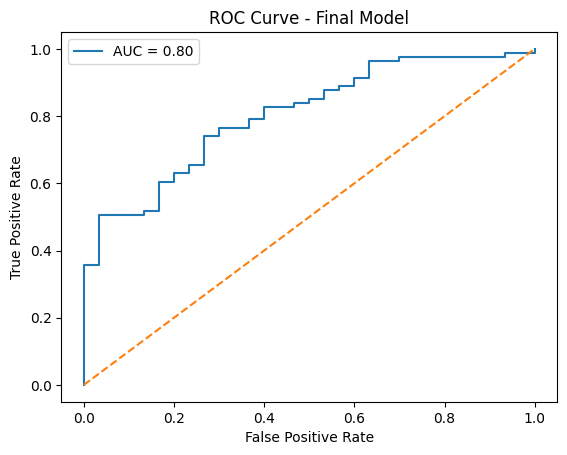

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Model")
plt.legend()
plt.savefig("roc_curve.png", bbox_inches='tight')
plt.show()

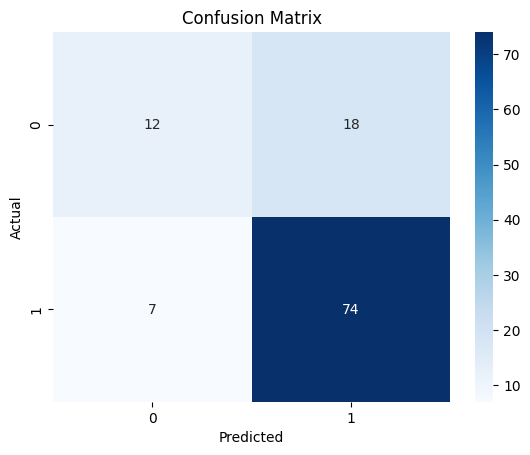

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png", bbox_inches='tight')
plt.show()

In [ ]:
import shap
import pandas as pd
import numpy as np

# Ensure X_test_imputed_df is created by preprocessing X_test
# Access the preprocessor from the best_model pipeline
preprocessor_for_best_model = best_model.named_steps['preprocessor']

# Transform X_test using the preprocessor
X_test_processed_array = preprocessor_for_best_model.transform(X_test)

# Get feature names after preprocessing, using the previously defined function
# We need the original categorical and numerical column names for this function
# (These are available from variables `numeric_cols` and `categorical_cols`)

# Re-define get_preprocessor_feature_names if it's not globally accessible, or ensure it is.
# For now, assuming it's available as it was in cell a5c4b9c5.
# If not, the function would need to be moved here or defined again.

def get_preprocessor_feature_names(preprocessor, numeric_cols, categorical_cols):
    output_features = []
    output_features.extend(numeric_cols)
    ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
    output_features.extend(ohe.get_feature_names_out(categorical_cols))
    return output_features

processed_feature_names = get_preprocessor_feature_names(preprocessor_for_best_model, numeric_cols, categorical_cols)

# Convert the processed array to a DataFrame with correct feature names
X_test_imputed_df = pd.DataFrame(X_test_processed_array, columns=processed_feature_names)

# Prepare background data for SHAP TreeExplainer
# This helps the explainer understand the feature distributions
X_train_processed_array = preprocessor_for_best_model.transform(X_train)
X_train_processed_df = pd.DataFrame(X_train_processed_array, columns=processed_feature_names)

# Sample a small portion of the processed training data for the background dataset
# Using a small sample (e.g., 100 rows) is usually sufficient and faster
background_data = shap.sample(X_train_processed_df, 100) # Use 100 samples as background

# Initialize SHAP explainer using the model part of the pipeline and background data
explainer = shap.TreeExplainer(best_model.named_steps['model'], data=background_data)

# Calculate SHAP values
# For classification, shap_values usually returns a list of arrays, one for each class.
# We want the values for the positive class (index 1).
shap_values = explainer.shap_values(X_test_imputed_df)
shap_positive = shap_values[1]

# Generate the summary plot
shap.summary_plot(shap_positive, X_test_imputed_df)